# F3 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F3 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F3 (3D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 3
N_DIMS = 3
N_INITIAL = 15
WEEK = 10
USE_LOG_SCALE = False
DATA_DIR = '../../data/f3/'

## Step 1 — Load Data

In [2]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F3 — Week 10 Data Summary
  Input dimensions:  3
  Total samples:     25
  Initial samples:   15
  Submissions:       10
  Input shape:       (25, 3)
  Output shape:      (25,)
  Best output:       -0.0314274
  Worst output:      -0.398926

Sample | x1 | x2 | x3 | y
-------------------------------------------------------------
   1(init) | 0.171525 | 0.343917 | 0.248737 | -0.112122
   2(init) | 0.242114 | 0.644074 | 0.272433 | -0.0879629
   3(init) | 0.534906 | 0.398501 | 0.173389 | -0.111415
   4(init) | 0.492581 | 0.611593 | 0.340176 | -0.0348353
   5(init) | 0.134622 | 0.219917 | 0.458206 | -0.0480076
   6(init) | 0.345523 | 0.941360 | 0.269363 | -0.110621
   7(init) | 0.151837 | 0.439991 | 0.990882 | -0.398926
   8(init) | 0.645503 | 0.397143 | 0.919771 | -0.113869
   9(init) | 0.746912 | 0.284196 | 0.226300 | -0.131461
  10(init) | 0.170477 | 0.697032 | 0.149169 | -0.0941896
  11(init) | 0.220549 | 0.297825 | 0.343555 | -0.0469474
  12(init) | 0.666014 | 0.671985 | 0.246295 | -0.1

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

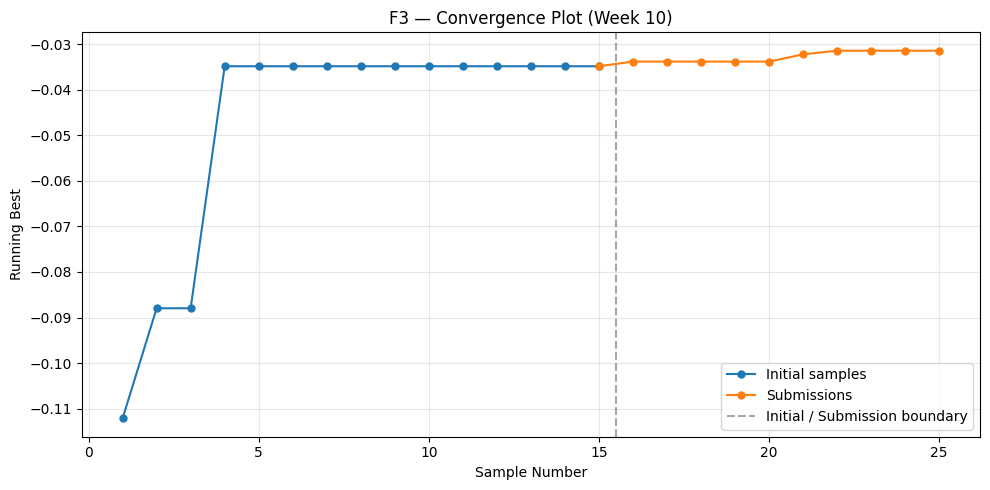

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

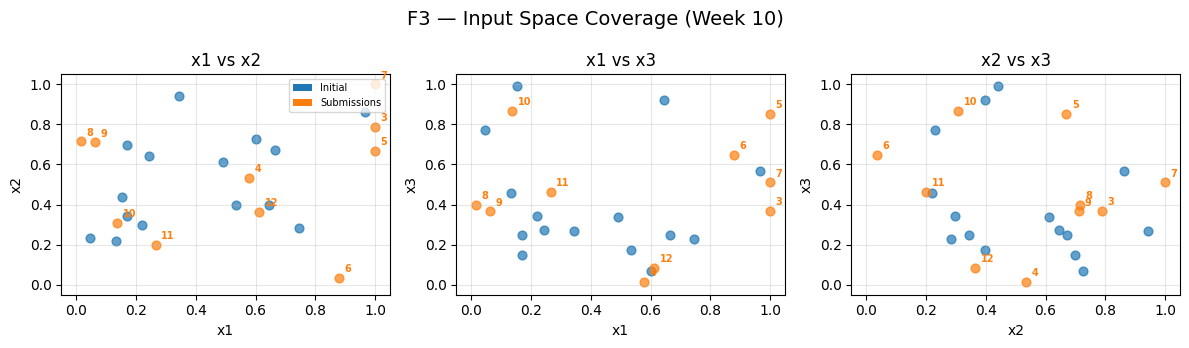

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: SFGP Matérn-2.5 ARD, Standardize(m=1)
- **Acquisition**: qLogNEI q=1
- **Key hyperparameters**: 20 restarts, 512 raw samples, noise_lb=1e-6

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -0.0348353
Best value (final):       -0.0314274
Improvements:             3/10
Max consecutive no-improve: 4
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |     -0.0338177 |     -0.0338177 | ✓
   4 |     -0.0725691 |     -0.0338177 | ✗
   5 |     -0.0394179 |     -0.0338177 | ✗
   6 |      -0.187072 |     -0.0338177 | ✗
   7 |      -0.049512 |     -0.0338177 | ✗
   8 |     -0.0322214 |     -0.0322214 | ✓
   9 |     -0.0314274 |     -0.0314274 | ✓
  10 |      -0.050946 |     -0.0314274 | ✗
  11 |     -0.0343614 |     -0.0314274 | ✗
  12 |     -0.0377062 |     -0.0314274 | ✗


### Evaluation

F3 has shown **slow progress** with **3 improvements** in 10 submission rounds. The best value moved from -0.0348 (initial) to -0.0314, a small improvement (output is negative, closer to zero is better for maximisation).

Key observations:
- 3/10 submissions improved the running best — some signal of progress but with long gaps
- Maximum 4 consecutive non-improving submissions indicates intermittent stalling
- The Standardize(m=1) transform is helping the GP model the negative-valued landscape
- With q=1, only one candidate is proposed per round — this limits both exploration and the chance of finding improvements
- The 3D input space means 3 pair plots provide full coverage of input relationships

**Stalling status**: YES (borderline) — 4 consecutive submissions without improvement meets the ≥3 threshold.

## Step 5 — Proposed Strategy Improvements

F3 is showing slow progress (3/10 improvements). The following refinements could accelerate improvement:

1. **Increase batch size from q=1 to q=2 or q=3** — With only 1 candidate per round, the chance of finding an improving point is low. Increasing q provides more evaluations per round and better covers the 3D space.

2. **Increase raw samples from 512 to 2048** — The acquisition optimiser uses relatively few seed points. More raw samples improve the chance of finding the global acquisition optimum.

3. **Review noise floor** — The noise_lb=1e-6 may be too tight for the negative-valued outputs, causing the GP to overfit individual observations rather than learning smooth trends.

4. **Consider alternative output transform** — The current Standardize(m=1) may not be optimal for the all-negative landscape. A shift transform (y - y_min) could map outputs to positive territory before GP fitting.

5. **Increase MLL restarts from 20 to 40** — In 3D with negative outputs, the GP likelihood surface may have multiple modes. More restarts reduce the risk of poor hyperparameters.

**Priority**: MEDIUM — F3 is making progress but too slowly given the remaining submission rounds.